- 단어를 밀집 벡터로 표현하는 방법은 단어의 의미 역시 벡터화할 수 있어야 함

## 1. 분산 표현(Distributed Representation)
- [분산 표현](../11.%20Bag%20of%20Words%20and%20TF-IDF/11-01.%20representations_of_words.ipynb)은 `분포 가설(Distributional Hypothesis)`에 기반함
- 이는 `분포적 유사성(Distributional Similiarity)`이 높은 단어들은 `의미적 유사성(Semantic Similarity)`이 높다는 가설임
- 분포가 유사한 단어들은 유사한 벡터를, 분포가 상이한 단어들은 상이한 벡터를 갖도록 주어진 차원의 벡터 공간으로 적합시키면, 이러한 벡터는 곧 단어의 의미를 표현하게 됨
- NNLM, RNNLM 등 여러 방법론이 있으며, 최근에는 속도를 대폭 개선시킨 `Word2Vec`가 많이 쓰임

## 2. Word2Vec의 구현 알고리즘
- Word2Vec은 `CBOW(Continuous Bag of Words)`와 `Skip-Gram` 두 방식이 있음
  - CBOW는 주변에 있는 단어들로 중간에 있는 단어들을 예측
  - Skip-Gram은 중간에 있는 단어로 주변 단어들을 예측
- 학습이 완료되면 단어의 원-핫 벡터에 해당하는 가중치 값을 임베딩 벡터로 사용

### 2.1 CBOW(Continuous Bag of Words)
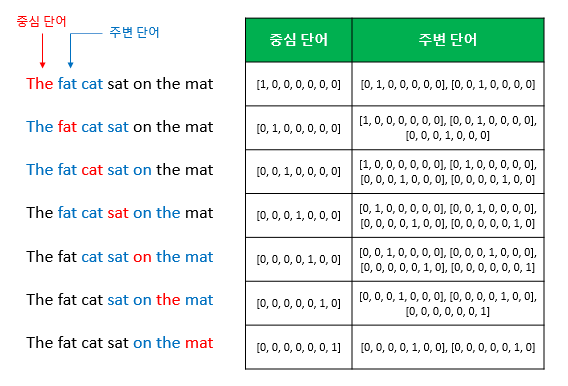
- `중심 단어(Center Word)`를 예측하기 위해 사용되는 `주변 단어(Context Word)`의 크기를 `윈도우(Window)`라고 함

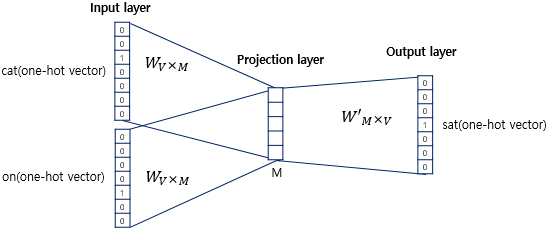
- 모델의 구조
  - 입력층: 주변 단어들의 원-핫 벡터를 윈도우 크기만큼 입력으로 받으며, 활성화 함수가 존재하지 않음
  - 투사층: 은닉층으로, 활성화 함수가 존재하지 않음
    - 입력 단어의 원-핫 벡터에 해당하는 $W_{v\times m}$의 행을 불러오는 작업(룩업 연산)에 해당
  - 출력층: 중심 단어의 원-핫 벡터와 같은 크기를 지니며, 활성화 함수로 `Softmax`를 사용함
- 모델의 크기
  - `M`: `투사층(Projection Layer)`의 크기로, 반환된 임베딩 벡터의 크기가 됨
  - `V`: 단어 집합의 크기
- 가중치
  - $W_{v\times m}$: 입력층 -> 투사층
  - $W'_{m\times v}$: 투사층 -> 출력층
- 오차 함수
  - 출력층의 결과값과 중심 단어의 원-핫 벡터를 구함

### 2.2 Skip-gram
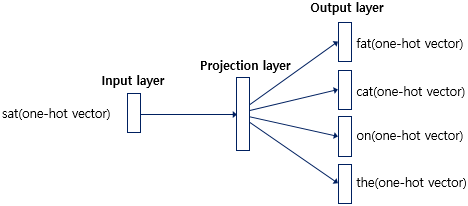
- CBOW를 역방향으로 적용

## 3. 네거티브 샘플링
- Word2Vec의 알고리즘은 출력 단계에서 단어 집합 전체에 대해 `Softmax` 연산을 수행하며, 이는 비용이 매우 큰 작업임
- 이를 효율화하기 위해 두 가지 기법을 적용
  - 전체 단어 집합 대신 샘플링된 단어 집합을 사용: 긍정 샘플(Positive Sample)과 부정 샘플(Negative Sample)로 구성
  - `Softmax` 연산을 통한 다중 레이블 분류를 이진 분류로 전환: 정답 단어에 대해 1, 오답 단어에 대해 0
- 네거티브 샘플링의 대상 단어는 무작위 샘플링보다는 해당 단어의 등장확률을 이용해 샘플링하는 경우가 많다
  - 등장확률이 높은 단어는 자주 샘플링해 더 정확히 임베딩해야 하며, 등장확률이 낮은 단어는 그렇지 않음
  - 등장확률이 낮은 단어라면 코퍼스 내에서 임베딩을 위한 충분한 데이터가 주어지지 않음
  - 등장확률을 샘플확률로 사용하면 샘플의 다양성을 확보하기 어려울 수 있으므로, 일반적으로 아래의 보정을 거침

$$ P(w_i) = \frac{f(w_i)^{0.75}}{\sum_{j=0}^n f(w_j)^{0.75}} $$